**1. Install Dependencies (Colab Setup)**

In [1]:
# Install PyTorch (Colab usually has it)
!pip install opencv-python matplotlib pycocotools

# Install Detectron2
!pip install 'git+https://github.com/facebookresearch/detectron2.git'

  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-dq1pelo2
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-dq1pelo2
  Resolved https://github.com/facebookresearch/detectron2.git to commit 8a9d885b3d4dcf1bef015f0593b872ed8d32b4ab
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 33.4 MB/s eta 0:00:00
  Created wheel for detectron2: filename=detectron2-0.6-cp312-cp312-linux_x86_64.whl size=7111486 sha2

**2. Mount Google Drive (Dataset Storage)**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Unzip files**

In [3]:
!unzip /content/drive/MyDrive/coco-segmentation-datasets.zip -d datasets/

Archive:  /content/drive/MyDrive/coco-segmentation-datasets.zip
  inflating: datasets/README.dataset.txt  
  inflating: datasets/README.roboflow.txt  
   creating: datasets/test/
 extracting: datasets/test/1616_jpg.rf.038d8c65bfd4909416d2069474350593.jpg  
 extracting: datasets/test/1675_jpg.rf.8ac45b207a19d89d94191a9a8e944391.jpg  
 extracting: datasets/test/1686_jpg.rf.4223f32dc8c87b73d2e3fac278264291.jpg  
 extracting: datasets/test/1706_jpg.rf.3da7e566fba1310b8025e55ba3f40bc6.jpg  
 extracting: datasets/test/1716_jpg.rf.cb68ec28e48b8253528328ab3792cb03.jpg  
 extracting: datasets/test/1722_jpg.rf.0329926c1ac4e54de6ca1e3ee5d523fe.jpg  
 extracting: datasets/test/1794_jpg.rf.a65b73c20b2e993f5c01c9f88b5c055c.jpg  
 extracting: datasets/test/1804_jpg.rf.61c5496144d32b209101001eed1bf389.jpg  
 extracting: datasets/test/1806_jpg.rf.fa13f0082f6bc69fe51523737dc946a1.jpg  
 extracting: datasets/test/1813_jpg.rf.ff629ec9aa4207d77a51fbc1174bbc37.jpg  
 extracting: datasets/test/1818_jpg.rf.cf

**cleanse Data**

In [26]:
import json

DATASET_PATH = "/content/datasets"

datasets = [
    ("train/_annotations.coco.json", "/content/train_fixed.coco.json"),
    ("valid/_annotations.coco.json", "/content/valid_fixed.coco.json"),
]

for input_path, output_path in datasets:
    full_input_path = f"{DATASET_PATH}/{input_path}"

    with open(full_input_path) as f:
        data = json.load(f)

    # Keep only ONE category
    data["categories"] = [{"id": 1, "name": "crack"}]

    # Fix all annotations
    for ann in data["annotations"]:
        ann["category_id"] = 1

    # Save
    with open(output_path, "w") as f:
        json.dump(data, f)

    print(f"✅ Fixed: {input_path} → {output_path}")

✅ Fixed: train/_annotations.coco.json → /content/train_fixed.coco.json
✅ Fixed: valid/_annotations.coco.json → /content/valid_fixed.coco.json


**3. Register Dataset (COCO Format)**

In [27]:
from detectron2.data.datasets import register_coco_instances

DATASET_PATH = "/content/datasets"

register_coco_instances(
    "crack_train",
    {},
    "/content/train_fixed.coco.json",
    f"{DATASET_PATH}/train/"
)

register_coco_instances(
    "crack_valid",
    {},
    "/content/valid_fixed.coco.json",
    f"{DATASET_PATH}/valid/"
)



**4. Visualize Dataset (Sanity Check)**

[04/05 12:32:16 d2.data.datasets.coco]: Loaded 3717 images in COCO format from /content/train_fixed.coco.json


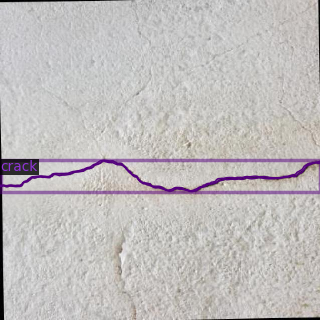

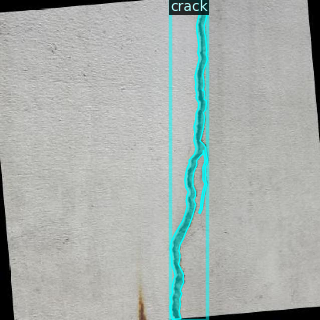

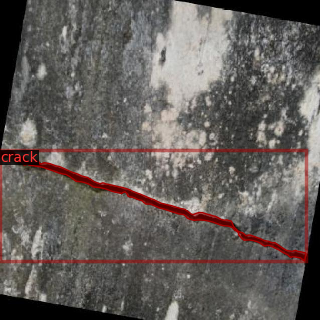

In [28]:
import random
import cv2
from google.colab.patches import cv2_imshow
from detectron2.utils.visualizer import Visualizer
from detectron2.data import DatasetCatalog, MetadataCatalog

dataset_dicts = DatasetCatalog.get("crack_train")
metadata = MetadataCatalog.get("crack_train")

for d in random.sample(dataset_dicts, 3):
    img = cv2.imread(d["file_name"])
    visualizer = Visualizer(img[:, :, ::-1], metadata=metadata, scale=0.5)
    out = visualizer.draw_dataset_dict(d)

    cv2_imshow(out.get_image()[:, :, ::-1])
    cv2.waitKey(0)

**5. Configure Model (Mask R-CNN)**

In [29]:
from detectron2.config import get_cfg
from detectron2 import model_zoo
import os

cfg = get_cfg()

cfg.merge_from_file(
    model_zoo.get_config_file(
        "COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"
    )
)

cfg.DATASETS.TRAIN = ("crack_train",)
cfg.DATASETS.TEST = ("crack_valid",)

cfg.DATALOADER.NUM_WORKERS = 2

cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url(
    "COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"
)

cfg.SOLVER.IMS_PER_BATCH = 2
cfg.SOLVER.BASE_LR = 0.00025
cfg.SOLVER.MAX_ITER = 4000
cfg.SOLVER.STEPS = []

cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1  # crack only

cfg.TEST.EVAL_PERIOD = 200   # ⭐ MUST BE HERE

cfg.OUTPUT_DIR = "/content/output"
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

**6. Train Model**

In [30]:
from detectron2.engine import DefaultTrainer

trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=False)

trainer.train()

[04/05 12:33:55 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, weight}
roi_heads.mask_head.predictor.{bias, weight}


[04/05 12:33:56 d2.engine.train_loop]: Starting training from iteration 0
[04/05 12:34:04 d2.utils.events]:  eta: 0:23:25  iter: 19  total_loss: 1.987  loss_cls: 0.8189  loss_box_reg: 0.2514  loss_mask: 0.6917  loss_rpn_cls: 0.1143  loss_rpn_loc: 0.0491    time: 0.3536  last_time: 0.3903  data_time: 0.0155  last_data_time: 0.0089   lr: 4.9953e-06  max_mem: 2097M
[04/05 12:34:11 d2.utils.events]:  eta: 0:23:21  iter: 39  total_loss: 1.801  loss_cls: 0.6726  loss_box_reg: 0.279  loss_mask: 0.6538  loss_rpn_cls: 0.1256  loss_rpn_loc: 0.05974    time: 0.3587  last_time: 0.3575  data_time: 0.0072  last_data_time: 0.0054   lr: 9.9902e-06  max_mem: 2097M
[04/05 12:34:19 d2.utils.events]:  eta: 0:23:29  iter: 59  total_loss: 1.508  loss_cls: 0.4552  loss_box_reg: 0.2604  loss_mask: 0.574  loss_rpn_cls: 0.1102  loss_rpn_loc: 0.06614    time: 0.3631  last_time: 0.4097  data_time: 0.0075  last_data_time: 0.0087   lr: 1.4985e-05  max_mem: 2097M
[04/05 12:34:26 d2.utils.events]:  eta: 0:23:41  iter

**7. Evaluation (mAP)**

In [31]:
from detectron2.evaluation import COCOEvaluator
from detectron2.data import build_detection_test_loader

evaluator = COCOEvaluator("crack_valid", cfg, False, output_dir=cfg.OUTPUT_DIR)
val_loader = build_detection_test_loader(cfg, "crack_valid")

trainer.test(cfg, trainer.model, evaluators=[evaluator])

WARNING [04/05 12:59:08 d2.evaluation.coco_evaluation]: COCO Evaluator instantiated using config, this is deprecated behavior. Please pass in explicit arguments instead.
[04/05 12:59:08 d2.data.datasets.coco]: Loaded 200 images in COCO format from /content/valid_fixed.coco.json
[04/05 12:59:08 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[04/05 12:59:08 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[04/05 12:59:08 d2.data.common]: Serializing 200 elements to byte tensors and concatenating them all ...
[04/05 12:59:09 d2.data.common]: Serialized dataset takes 0.67 MiB
[04/05 12:59:09 d2.data.datasets.coco]: Loaded 200 images in COCO format from /content/valid_fixed.coco.json
[04/05 12:59:09 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max

OrderedDict([('bbox',
              {'AP': 57.36765328064949,
               'AP50': 80.61903918383275,
               'AP75': 66.06550841799064,
               'APs': 0.23186578515640832,
               'APm': 10.346514137258914,
               'APl': 64.41472214193445}),
             ('segm',
              {'AP': 3.1508050210573257,
               'AP50': 14.62395170331528,
               'AP75': 0.26250988595201447,
               'APs': 0.003631418101432473,
               'APm': 0.11189981377575037,
               'APl': 11.387359945446942})])

**Plot Metrics**

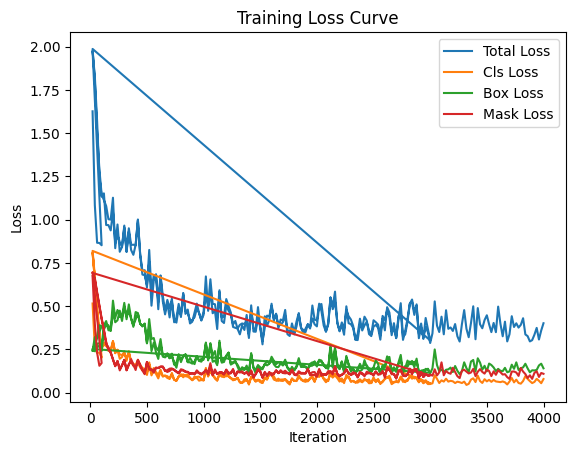

⚠️ No evaluation metrics found. Did you set cfg.TEST.EVAL_PERIOD?


In [32]:
import pandas as pd

metrics_file = "/content/output/metrics.json"

data = []
with open(metrics_file, "r") as f:
    for line in f:
        data.append(json.loads(line))

df = pd.DataFrame(data)

# Plot training loss

plt.figure()
plt.plot(df["iteration"], df["total_loss"], label="Total Loss")

if "loss_cls" in df:
    plt.plot(df["iteration"], df["loss_cls"], label="Cls Loss")

if "loss_box_reg" in df:
    plt.plot(df["iteration"], df["loss_box_reg"], label="Box Loss")

if "loss_mask" in df:
    plt.plot(df["iteration"], df["loss_mask"], label="Mask Loss")

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.title("Training Loss Curve")
plt.show()

# Plot evaluation metrics
if "bbox/AP" in df.columns:
    eval_df = df[df["bbox/AP"].notna()]

    plt.figure()
    plt.plot(eval_df["iteration"], eval_df["bbox/AP"], label="AP")
    plt.plot(eval_df["iteration"], eval_df["bbox/AP50"], label="AP50")

    plt.legend()
    plt.title("Detection Performance")
    plt.show()
else:
    print("⚠️ No evaluation metrics found. Did you set cfg.TEST.EVAL_PERIOD?")


# Segmentation metrics (if available)
if "segm/AP" in df:
    segm_df = df[df["segm/AP"].notna()]

    plt.figure()
    plt.plot(segm_df["iteration"], segm_df["segm/AP"], label="Mask AP")

    plt.xlabel("Iteration")
    plt.ylabel("Score")
    plt.legend()
    plt.title("Segmentation Performance")
    plt.show()

**8. Inference**

In [33]:
from detectron2.engine import DefaultPredictor

cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5

predictor = DefaultPredictor(cfg)

[04/05 13:01:17 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/output/model_final.pth ...


**Run Prediction**

(np.float64(-0.5), np.float64(511.5), np.float64(339.5), np.float64(-0.5))

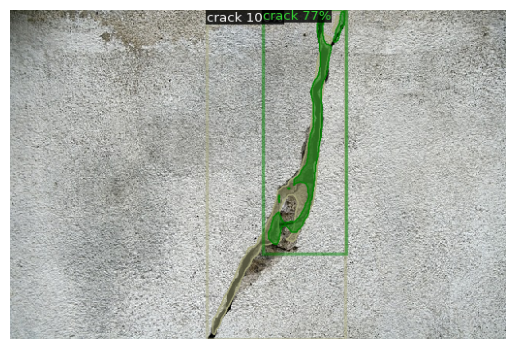

In [38]:
import matplotlib.pyplot as plt

image_path = "/content/test.jpg"
image = cv2.imread(image_path)

outputs = predictor(image)

v = Visualizer(image[:, :, ::-1], metadata=metadata, scale=0.8)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

plt.imshow(out.get_image())
plt.axis("off")

**9. Save Model to Drive**

In [22]:
!cp /content/output/model_final.pth /content/drive/MyDrive/crack_model.pth

**Dataset Reference:** [Roboflow Crack Instance segmentation Datasets](https://universe.roboflow.com/roboflow-jvuqo/creacks-eapny/dataset/8)